
Uses `model.model.ABSAModel` (multi-head, softmax)  
`model.train.train_model` (Hugging face trainer, weighted cross-entropy).

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import random_split
from transformers import AutoTokenizer, set_seed
import transformers

from config.global_config import SENTIMENT_LABELS, TRAIN_ASPECTS
from model.model import ABSAModel
from model.prepare_dataset import ABSADataset
from model.train import train_model, compute_class_weights

transformers.logging.set_verbosity_error()

MODEL_NAME = "bert-base-uncased"
DATA_PATH = "statics/datasets/training.csv"
SAVE_DIR = "saved_models"
VAL_RATIO = 0.2
SEED = 25

set_seed(SEED)
print(f"Model:      {MODEL_NAME}")
print(f"Aspects:    {TRAIN_ASPECTS}")
print(f"Sentiments: {SENTIMENT_LABELS}")

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model:      bert-base-uncased
Aspects:    ['safety', 'cleanliness', 'infrastructure', 'nature', 'attractions', 'heritage', 'costs', 'other']
Sentiments: ['positive', 'neutral', 'negative', 'notmentioned']


In [2]:
df = pd.read_csv(DATA_PATH)
df[TRAIN_ASPECTS] = df[TRAIN_ASPECTS].fillna("notmentioned")
print(f"Loaded {len(df)} examples")

for aspect in TRAIN_ASPECTS:
    print(f"  {aspect}: {dict(df[aspect].value_counts())}")

Loaded 1000 examples
  safety: {'notmentioned': np.int64(845), 'negative': np.int64(66), 'positive': np.int64(48), 'neutral': np.int64(41)}
  cleanliness: {'notmentioned': np.int64(871), 'negative': np.int64(48), 'positive': np.int64(48), 'neutral': np.int64(33)}
  infrastructure: {'notmentioned': np.int64(851), 'positive': np.int64(61), 'negative': np.int64(52), 'neutral': np.int64(36)}
  nature: {'notmentioned': np.int64(881), 'neutral': np.int64(47), 'negative': np.int64(42), 'positive': np.int64(30)}
  attractions: {'notmentioned': np.int64(870), 'positive': np.int64(48), 'negative': np.int64(44), 'neutral': np.int64(38)}
  heritage: {'notmentioned': np.int64(878), 'neutral': np.int64(50), 'negative': np.int64(41), 'positive': np.int64(31)}
  costs: {'notmentioned': np.int64(859), 'positive': np.int64(61), 'negative': np.int64(49), 'neutral': np.int64(31)}
  other: {'notmentioned': np.int64(828), 'positive': np.int64(84), 'negative': np.int64(44), 'neutral': np.int64(44)}


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset = ABSADataset(df, tokenizer)
labels_np = dataset.get_labels_numpy()

val_size = max(1, int(len(dataset) * VAL_RATIO))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Tokenizer step:
Finished! 1000 examples, label shape torch.Size([1000, 8])
  Aspects: 8, Sentiments: 4

Train: 800, Val: 200


In [4]:
from collections import defaultdict

class_weights = compute_class_weights(labels_np)
print(f"Class weights: {class_weights}")

model = ABSAModel(MODEL_NAME, class_weights=class_weights)
print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

trainer = train_model(
    model=model,
    train_dataset=train_ds,
    val_dataset=val_ds,
    output_dir="./results",
)

epoch_train_losses: dict[int, list[float]] = defaultdict(list)
epoch_eval: dict[int, dict] = {}

for entry in trainer.state.log_history:
    ep = int(entry.get("epoch", 0))
    if "loss" in entry and "eval_loss" not in entry:
        epoch_train_losses[ep].append(entry["loss"])
    elif "eval_loss" in entry:
        epoch_eval[ep] = entry

history = []
for ep in sorted(epoch_eval):
    ev = epoch_eval[ep]
    train_losses = epoch_train_losses.get(ep, [])
    avg_train_loss = sum(train_losses) / len(train_losses) if train_losses else None
    history.append({
        "epoch": ep,
        "train_loss": avg_train_loss,
        "eval_loss": ev.get("eval_loss"),
        "eval_sentiment_f1": ev.get("eval_sentiment_f1"),
        "eval_macro_f1": ev.get("eval_macro_f1"),
    })

print(f"\nTraining history ({len(history)} epochs):")
for h in history:
    print(f"  Epoch {h['epoch']}: train_loss={h['train_loss']:.4f}, eval_loss={h['eval_loss']:.4f}, "
          f"sentiment_f1={h['eval_sentiment_f1']:.4f}, macro_f1={h['eval_macro_f1']:.4f}")

Class weights: tensor([4.8662, 6.2500, 5.1813, 0.2906])


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7386.56it/s]


Total params:     109,506,848
Trainable params: 109,506,848
{'loss': '1.24', 'grad_norm': '3.717', 'learning_rate': '5e-05', 'epoch': '0.4'}
{'loss': '0.9425', 'grad_norm': '2.732', 'learning_rate': '5e-05', 'epoch': '0.8'}
{'eval_loss': '0.7269', 'eval_sentiment_f1': '0.3134', 'eval_macro_f1': '0.3731', 'eval_sent_0_f1': '0.3171', 'eval_sent_1_f1': '0.297', 'eval_sent_2_f1': '0.3261', 'eval_sent_3_f1': '0.5519', 'eval_runtime': '1.881', 'eval_samples_per_second': '106.3', 'eval_steps_per_second': '13.29', 'epoch': '1'}
{'loss': '0.7745', 'grad_norm': '1.795', 'learning_rate': '5e-05', 'epoch': '1.2'}
{'loss': '0.6251', 'grad_norm': '2.122', 'learning_rate': '5e-05', 'epoch': '1.6'}
{'loss': '0.5012', 'grad_norm': '1.104', 'learning_rate': '5e-05', 'epoch': '2'}
{'eval_loss': '0.4789', 'eval_sentiment_f1': '0.4873', 'eval_macro_f1': '0.5702', 'eval_sent_0_f1': '0.5736', 'eval_sent_1_f1': '0.4706', 'eval_sent_2_f1': '0.4176', 'eval_sent_3_f1': '0.8188', 'eval_runtime': '1.706', 'eval_sa

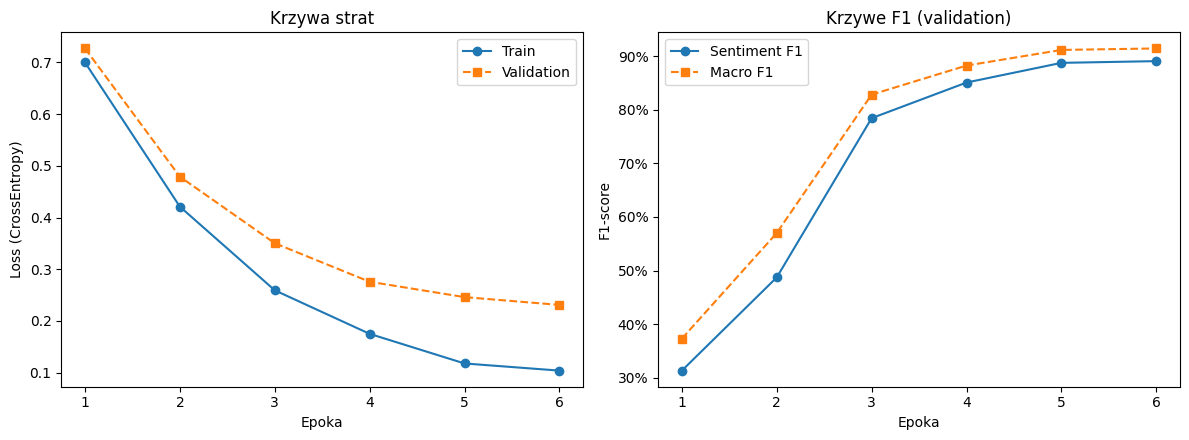

Najlepsza epoka (min eval_loss): 6 — eval_loss=0.2311, sentiment_f1=0.8907
Luka generalizacyjna (epoka 6): Δloss=-0.1270
→ Uwaga: możliwe przeuczenie


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import json

h = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(h["epoch"], h["train_loss"], "o-", label="Train")
ax1.plot(h["epoch"], h["eval_loss"], "s--", label="Validation")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Loss (CrossEntropy)")
ax1.set_title("Krzywa strat")
ax1.legend()
ax1.set_xticks(h["epoch"])

ax2.plot(h["epoch"], h["eval_sentiment_f1"], "o-", label="Sentiment F1")
ax2.plot(h["epoch"], h["eval_macro_f1"], "s--", label="Macro F1")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("F1-score")
ax2.set_title("Krzywe F1 (validation)")
ax2.legend()
ax2.set_xticks(h["epoch"])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

gap_loss = h.iloc[-1]["train_loss"] - h.iloc[-1]["eval_loss"]
best_val = h.loc[h["eval_loss"].idxmin()]

print(f"Najlepsza epoka (min eval_loss): {int(best_val['epoch'])} — eval_loss={best_val['eval_loss']:.4f}, sentiment_f1={best_val['eval_sentiment_f1']:.4f}")
print(f"Luka generalizacyjna (epoka {int(h.iloc[-1]['epoch'])}): Δloss={gap_loss:+.4f}")
print(f"{'→ Brak oznak przeuczenia (eval_loss ≤ train_loss)' if gap_loss >= 0 else '→ Uwaga: możliwe przeuczenie'}")

In [6]:
import json
os.makedirs(SAVE_DIR, exist_ok=True)

safe_name = MODEL_NAME.replace("/", "_")
save_path = os.path.join(SAVE_DIR, f"{safe_name}_absa.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "base_model_name": MODEL_NAME,
    },
    save_path,
)
print(f"Model saved → {save_path}")

history_path = os.path.join(SAVE_DIR, f"{safe_name}_training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {history_path}")

Model saved → saved_models/bert-base-uncased_absa.pt
Training history saved → saved_models/bert-base-uncased_training_history.json


---
## Load the saved model & run inference

In [10]:
from model.model import ABSAModel
from model.predict import predict
from transformers import AutoTokenizer

checkpoint = torch.load(save_path, weights_only=False)
base_model_name = checkpoint["base_model_name"]
print(f"Rebuilding model from backbone: {base_model_name}")

loaded_model = ABSAModel(base_model_name)
loaded_model.load_state_dict(checkpoint["model_state_dict"], strict=False)
loaded_model.eval()

loaded_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
print("Model loaded successfully!")

Rebuilding model from backbone: bert-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7302.48it/s]


Model loaded successfully!


In [11]:
test_texts = [
    "This park is dirty and unsafe at night, the paths are broken.",
    "Beautiful museum with free entry and amazing historical exhibitions!",
]

for text in test_texts:
    results, probabilities = predict(text, loaded_model, loaded_tokenizer)

    print(f"\n>>> {text}")
    active = {k: v for k, v in results.items() if v != "notmentioned"}
    print(f"  Active sentiments: {active if active else 'None'}")
    print(f"  Full predictions:  {results}")


>>> This park is dirty and unsafe at night, the paths are broken.
  Active sentiments: {'safety': 'negative', 'cleanliness': 'negative', 'infrastructure': 'negative'}
  Full predictions:  {'safety': 'negative', 'cleanliness': 'negative', 'infrastructure': 'negative', 'nature': 'notmentioned', 'attractions': 'notmentioned', 'heritage': 'notmentioned', 'costs': 'notmentioned', 'other': 'notmentioned'}

>>> Beautiful museum with free entry and amazing historical exhibitions!
  Active sentiments: {'safety': 'positive', 'infrastructure': 'positive', 'attractions': 'positive', 'heritage': 'positive', 'other': 'positive'}
  Full predictions:  {'safety': 'positive', 'cleanliness': 'notmentioned', 'infrastructure': 'positive', 'nature': 'notmentioned', 'attractions': 'positive', 'heritage': 'positive', 'costs': 'notmentioned', 'other': 'positive'}
